# Task 1: GPT-style character language model from scratch (TinyStories)

From-scratch multi-head causal self-attention, LayerNorm, FFN and residual blocks (`src/model.py`), learned token and positional embeddings, and an LM head. Trained with cross-entropy, linear warmup + cosine decay, and ≥10 epochs. All settings are in `config.yaml`.

In [1]:
# Works on a local kernel (this Mac: CUDA > Apple MPS > CPU) and on a Colab GPU runtime.
MEMBER = "sivasurya_chandran"
TASK = "task1_llm"
DRIVE_REPO = "/content/drive/MyDrive/DATA266/lab1/repo"   # used only on Colab

import os, sys, json, glob
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.isdir("/content/drive/MyDrive"):
        from google.colab import drive
        drive.mount("/content/drive")
    sys.path.insert(0, f"{DRIVE_REPO}/tools")
    import colab
    colab.setup(DRIVE_REPO, TASK, MEMBER)
else:
    if os.path.basename(os.getcwd()) == "src":   # VS Code starts the kernel next to the notebook
        os.chdir("..")
    sys.path.insert(0, os.path.abspath("../../tools"))
    import colab   # only launch()/monitor() are used locally
    import torch
    dev = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
    print("working in", os.path.relpath(os.getcwd(), os.path.abspath("../..")), "| torch", torch.__version__, "| device:", dev)

Mounted at /content/drive
$ rsync -a --exclude 'checkpoints/' --exclude 'logs/' --exclude 'outputs/' --exclude 'data_processed/' --exclude 'submission/' --exclude '*_smoketest*' --exclude '.venv/' --exclude '.git/' --exclude 'backups/' --exclude '/task2_sentiment/data/' --exclude '/task3_gan/data/' '/content/drive/MyDrive/DATA266/lab1/repo/' /content/repo/
$ pip install -q -r /content/repo/requirements-colab.txt
working in /content/repo/task1_llm/sivasurya_chandran
results persist in /content/drive/MyDrive/DATA266/lab1/repo/task1_llm/sivasurya_chandran
torch 2.11.0+cu128 | Tesla T4


## 1. Preprocessing: character tokenisation, `char_to_idx` / `idx_to_char`, 100K train / 10K validation stories, fixed-length input→target pairs

In [2]:
if not os.path.exists("data_processed/train.bin"):
    !python src/preprocess.py --config config.yaml
c2i = json.load(open("data_processed/char_to_idx.json"))
print("vocab size:", len(c2i), "| train chars:", os.path.getsize("data_processed/train.bin") // 2, "| val chars:", os.path.getsize("data_processed/val.bin") // 2)
print("vocabulary:", repr("".join(c2i)))

vocab size: 109 | train chars: 89823808 | val chars: 8991480
vocabulary: '\t\n !"#$&\'()*+,-./0123456789:;<>?ABCDEFGHIJKLMNOPQRSTUVWXYZ\\_`abcdefghijklmnopqrstuvwxyz\xa0£¦§©\xad±²´ÂÃâœŠ˜’“”‰‹€™'


## 2. Training

In [3]:
# Starts training in the background on the runtime (adds --resume automatically if checkpoints/train_state.pt exists).
colab.launch("python src/train.py --config config.yaml", done_file="checkpoints/gpt_final.pt", resumable=True)

started: python src/train.py --config config.yaml --resume


In [4]:
# Live tail of the unedited raw log. Interrupting this cell does NOT stop training; re-run it to keep watching.
colab.monitor(done_file="checkpoints/gpt_final.pt")

finished: checkpoints/gpt_final.pt


## 3. Training and validation loss curves

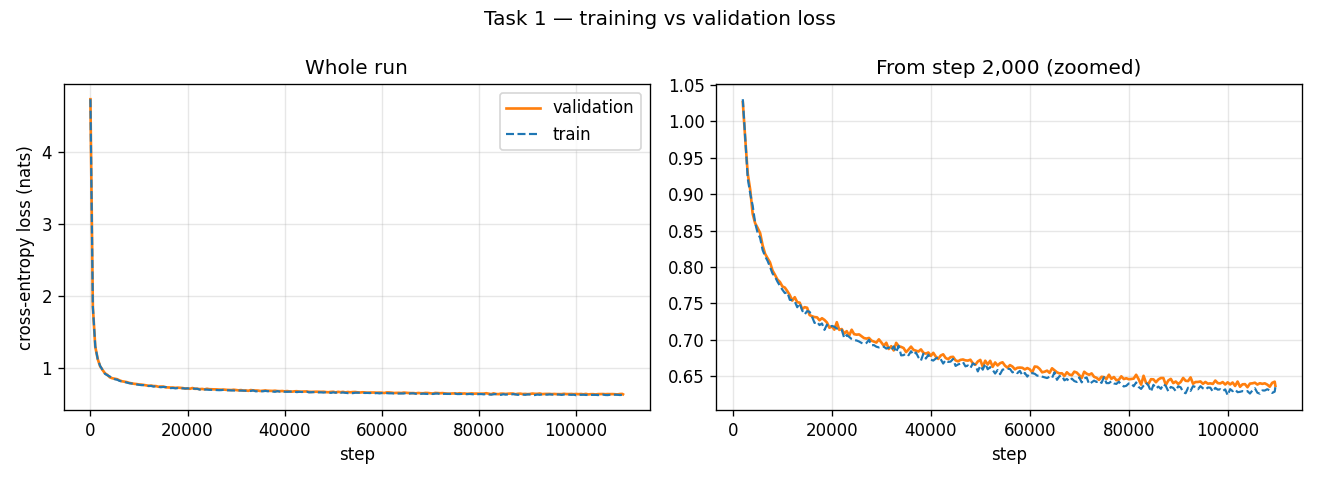

{
  "checkpoint": "checkpoints/gpt_final.pt",
  "param_count": 4827648,
  "train_cross_entropy": 0.6303482213616372,
  "val_cross_entropy": 0.638516144156456,
  "perplexity_val": 1.893668861900219,
  "perplexity_train": 1.878264517227855,
  "bits_per_character_val": 0.9211840747020615,
  "generalization_gap": 0.008167922794818816,
  "top1_next_char_accuracy_val": 0.795491943359375,
  "top1_next_char_accuracy_train": 0.7973394775390625,
  "grad_norm_mean": Infinity,
  "grad_norm_max": Infinity,
  "grad_norm_p95": 0.4908212199807157,
  "nan_steps": 0,
  "loss_spikes": 0,
  "training_time_sec": 6735.6416392326355,
  "training_tokens_per_sec": 133346.00148091087,
  "peak_memory_mb": 943.98681640625,
  "epochs": 10,
  "amp_fp16": true,
  "total_steps": 109640,
  "loss_curve_plot": "checkpoints/loss_curves.png"
}


In [5]:
from IPython.display import Image, display
display(Image("checkpoints/loss_curves.png"))
m = json.load(open("checkpoints/metrics_train.json"))
print(json.dumps({k: v for k, v in m.items() if k != "history"}, indent=2))

## 4. Text generation (greedy and temperature sampling) and generation metrics

In [6]:
if not os.path.exists("checkpoints/generation_metrics.json"):
    !python src/generate.py --config config.yaml --checkpoint checkpoints/gpt_final.pt
print(json.dumps(json.load(open("checkpoints/generation_metrics.json")), indent=2))
print(open("checkpoints/samples.txt").read()[:4000])

{
  "checkpoint": "checkpoints/gpt_final.pt",
  "decoding": {
    "temperature": 0.8,
    "top_k": null,
    "max_new_tokens": 300
  },
  "distinct_1": 0.25247971145175835,
  "distinct_2": 0.676416819012797,
  "distinct_3": 0.8860055607043559,
  "repeated_4gram_rate": 0.006250521498337508,
  "repeated_4gram_rate_pooled": 0.0461121157323689,
  "repeated_4gram_rate_greedy": 0.2671054031391333,
  "invented_word_rate": 0.007429227646618951,
  "generation_tokens_per_sec": 217.18323933975248,
  "num_samples": 20
}

--- sample (temperature) ---
Once upon a time, there was a farmer who loved to play outside. He would run and jump and throw the farmer and his fish. One day, the farmer wanted to pick some friends. So the farmer went to the park to play.

When the farmer was finished, he saw something else in the garden. It was a big box! He was so excited th
{
  "checkpoint": "checkpoints/gpt_final.pt",
  "decoding": {
    "temperature": 0.8,
    "top_k": null,
    "max_new_tokens": 300
  },
  "

## 5. Failure-case candidates (for `failure_analysis.md`)

In [7]:
for k, s in json.load(open("checkpoints/failure_candidates.json")).items():
    print(f"--- {k} ({s['mode']}, T={s['temperature']}, rep4={s['repeated_4gram_rate']:.3f}, invented={s['invented_word_rate']:.3f})\n{s['text'][:600]}\n")

--- most_repetitive (greedy, T=0.0, rep4=0.841, invented=0.000)
The sun was shining and the sky was blue. The sun was shining and the sky was blue. The sun was shining and the sky was blue. The sun was shining and the sky was blue. The sun was shining and the sky was blue. The sun was shining and the sky was blue. The sun was shining and the sky was blue. The sun was shining and the s

--- most_invented_words (temperature, T=0.8, rep4=0.015, invented=0.029)
Mom said, "Let me have a snack. I want to find some butter and some snacks for you."

They put some snacks and water and water and started to play with them all. They put their hands in and waited for the swan, but they were too strong and too late. The swans were gone forever. The swans were there, and the sw

--- greedy_example (greedy, T=0.0, rep4=0.000, invented=0.014)
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she went to the park with her mommy and daddy. They saw 

## 6. Metric table and deliverables

In [8]:
!cd ../.. && python tools/export_reports.py --member {MEMBER}
!cd ../.. && python tools/make_tables.py --member {MEMBER}
if IN_COLAB:
    colab.sync_back(DRIVE_REPO, TASK, MEMBER)

wrote task1_llm/sivasurya_chandran/metrics_report.csv
wrote task1_llm/sivasurya_chandran/failure_analysis.md
task2: no metrics yet
task3: no metrics yet
# Metric tables — sivasurya_chandran (from `checkpoints/`)


## Task 1

| Metric | Value |
|---|---|
| Training cross-entropy (nats/char) | 0.6303 |
| Validation cross-entropy (nats/char) | 0.6385 |
| Perplexity (val) | 1.8937 |
| Bits-per-character (val) | 0.9212 |
| Generalization gap (val − train) | 0.0082 |
| Top-1 next-char accuracy (val) | 0.7955 |
| Distinct-1 / 2 / 3 | 0.2525 / 0.6764 / 0.8860 |
| Repeated 4-gram rate (sampled / greedy) | 0.0063 / 0.2671 |
| Grad norm mean / p95 / max | inf / 0.491 / inf |
| NaN steps / loss spikes | 0 / 0 |
| Parameter count | 4,827,648 |
| Training tokens/sec | 133,346 |
| Generation tokens/sec | 217.1832 |
| Peak memory (MB) | 943.9868 |
| Total training time (s) | 6,735.6416 |

## Task 2

_no Task 2 metrics yet_

## Task 3

_no Task 3 metrics yet_

$ rsync -a --include='*.md' --exclude='*' 